<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/quant_DL_ashu/notebooks/15min/02B_Intraday_EDA_Statistical_Tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02B — Intraday EDA and Statistical Diagnostics

This notebook provides the formal EDA / statistical-diagnostics layer for the intraday volatility project.

It mirrors the useful diagnostics from the earlier daily-data EDA while adapting them to high-frequency data.

## Scope and leakage policy

The notebook uses **original Train-period observations only** for statistical diagnostics.

That is deliberate:

- Validation has already been used for model comparison;
- Test remains sealed;
- no EDA result from Validation/Test should influence the final LSTM design.

The return series itself is filtered by **candle time**, not model-target split, so every return included in EDA is realized strictly before the original Validation boundary.

## Core diagnostics

For BTC / ETH / SOL / XRP:

1. structural and continuity QC;
2. descriptive statistics;
3. annualized volatility using interval-aware crypto scaling;
4. return / absolute-return / squared-return distributions;
5. skewness and excess kurtosis;
6. Jarque–Bera normality test;
7. Student-t fit and KS diagnostic;
8. ADF stationarity test;
9. Phillips–Perron stationarity test;
10. KPSS stationarity test;
11. ACF diagnostics for returns, absolute returns and squared returns;
12. Ljung–Box tests at elapsed-time lags;
13. ARCH-LM test;
14. intraday time-of-day volatility seasonality;
15. day-of-week volatility seasonality;
16. cross-asset return and squared-return correlations;
17. rolling historical-volatility visualization.

## Important interpretation

With hundreds of thousands of high-frequency observations, formal tests can reject very small deviations from a null hypothesis.

Therefore statistical significance is interpreted together with:

- effect sizes;
- skewness / kurtosis;
- ACF magnitudes;
- plots;
- economic relevance.

No observations are trimmed or winsorized for the formal tests.

## 1. Imports and Drive

In [1]:
from google.colab import drive

from pathlib import Path
from datetime import datetime, timezone
import importlib.util
import json
import math
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

from statsmodels.tsa.stattools import (
    adfuller,
    kpss,
    acf,
)
from statsmodels.stats.diagnostic import (
    acorr_ljungbox,
    het_arch,
)
from statsmodels.graphics.gofplots import qqplot

if importlib.util.find_spec("arch") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "arch",
        ]
    )

from arch.unitroot import PhillipsPerron

drive.mount("/content/drive")

print("Imports complete.")

Mounted at /content/drive
Imports complete.


## 2. Configuration

In [2]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Quant Research/15min"
)

# Change only after the upstream 01/02 pipeline has been run
# for the corresponding interval.
KLINE_INTERVAL = "15m"

SYMBOLS = [
    "BTCUSDT",
    "ETHUSDT",
    "SOLUSDT",
    "XRPUSDT",
]

EPSILON = 1e-12

# Dynamic elapsed-time diagnostics.
DIAGNOSTIC_LAG_DURATIONS = [
    "1h",
    "4h",
    "12h",
    "1d",
]

ACF_MAX_DURATION = "1d"
ARCH_LM_DURATION = "4h"
ROLLING_VOLATILITY_WINDOW = "1d"

# Plot only the final part of Train for readable time-series charts.
TIMESERIES_PLOT_DURATION = "30d"

RESULTS_ROOT = (
    PROJECT_ROOT
    / "results"
    / KLINE_INTERVAL
    / "EDA"
)

FIGURE_ROOT = (
    RESULTS_ROOT
    / "figures"
)

MANIFEST_ROOT = (
    PROJECT_ROOT
    / "manifests"
    / KLINE_INTERVAL
)

RESULTS_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

print("Project:", PROJECT_ROOT)
print("Interval:", KLINE_INTERVAL)

Project: /content/drive/MyDrive/Quant Research/15min
Interval: 15m


## 3. Load Notebook 02 processing manifest and canonical data

In [3]:
manifest_candidates = sorted(
    MANIFEST_ROOT.glob(
        f"processing_manifest_{KLINE_INTERVAL}_v*.json"
    )
)

if len(manifest_candidates) != 1:
    raise FileNotFoundError(
        "Expected exactly one Notebook 02 processing manifest "
        f"for {KLINE_INTERVAL}; found "
        f"{len(manifest_candidates)}."
    )

PROCESSING_MANIFEST_PATH = (
    manifest_candidates[0]
)

processing_manifest = json.loads(
    PROCESSING_MANIFEST_PATH.read_text(
        encoding="utf-8"
    )
)

if (
    processing_manifest[
        "kline_interval"
    ]
    != KLINE_INTERVAL
):
    raise ValueError(
        "Processing-manifest interval mismatch."
    )

INTERVAL_MINUTES = int(
    processing_manifest[
        "interval_minutes"
    ]
)

INTERVAL_DELTA = pd.Timedelta(
    minutes=INTERVAL_MINUTES
)

split_cfg = (
    processing_manifest[
        "split_boundaries_utc"
    ]
)

VALIDATION_START = pd.Timestamp(
    split_cfg[
        "validation_target_start"
    ]
)

TEST_START = pd.Timestamp(
    split_cfg[
        "validation_target_end_exclusive"
    ]
)

FEATURES_PATH = Path(
    processing_manifest[
        "outputs"
    ][
        "full_features_parquet"
    ]
)

MODEL_ROWS_PATH = Path(
    processing_manifest[
        "outputs"
    ][
        "valid_model_rows_parquet"
    ]
)

RAW_PATH = Path(
    processing_manifest[
        "source_raw_parquet"
    ]
)

for path in [
    FEATURES_PATH,
    MODEL_ROWS_PATH,
    RAW_PATH,
]:
    if not path.exists():
        raise FileNotFoundError(
            f"Required upstream file missing:\n{path}"
        )

features_df = pd.read_parquet(
    FEATURES_PATH
)

canonical_model_rows_df = pd.read_parquet(
    MODEL_ROWS_PATH
)

raw_df = pd.read_parquet(
    RAW_PATH
)

features_df[
    "open_time"
] = pd.to_datetime(
    features_df[
        "open_time"
    ],
    utc=True,
    errors="raise",
)

canonical_model_rows_df[
    "open_time"
] = pd.to_datetime(
    canonical_model_rows_df[
        "open_time"
    ],
    utc=True,
    errors="raise",
)

canonical_model_rows_df[
    "target_open_time"
] = pd.to_datetime(
    canonical_model_rows_df[
        "target_open_time"
    ],
    utc=True,
    errors="raise",
)

raw_df[
    "open_time"
] = pd.to_datetime(
    raw_df[
        "open_time"
    ],
    utc=True,
    errors="raise",
)

print("Interval:", INTERVAL_DELTA)
print("Train-only EDA end:", VALIDATION_START)
print("Full feature rows:", len(features_df))
print("Canonical model rows:", len(canonical_model_rows_df))

Interval: 0 days 00:15:00
Train-only EDA end: 2024-08-01 00:00:00+00:00
Full feature rows: 1125147
Canonical model rows: 1114295


## 4. Structural / fixed-horizon QC

In [4]:
required_feature_columns = {
    "symbol",
    "open_time",
    "return",
    "realized_variance",
    "standard_duration_candle",
}

missing = (
    required_feature_columns
    - set(
        features_df.columns
    )
)

if missing:
    raise ValueError(
        f"Feature parquet missing columns: {missing}"
    )

assert not features_df.duplicated(
    [
        "symbol",
        "open_time",
    ]
).any()

assert (
    features_df[
        "symbol"
    ]
    .nunique()
    == len(
        SYMBOLS
    )
)

canonical_alignment = (
    canonical_model_rows_df[
        "target_open_time"
    ]
    - canonical_model_rows_df[
        "open_time"
    ]
)

assert canonical_alignment.eq(
    INTERVAL_DELTA
).all()

assert np.allclose(
    canonical_model_rows_df[
        "target_realized_variance"
    ].to_numpy(
        dtype=float
    ),
    (
        canonical_model_rows_df[
            "target_return"
        ].to_numpy(
            dtype=float
        )
        ** 2
    ),
    rtol=1e-10,
    atol=1e-18,
)

print(
    "Structural and canonical one-candle target QC passed."
)

Structural and canonical one-candle target QC passed.


## 5. Build the Train-only return series

Returns are retained only when:

- the candle itself occurs before Validation;
- the return is finite;
- the candle has standard configured duration;
- the current candle is exactly one configured interval after the previous observed candle.

This removes gap-crossing returns without modifying the raw source.

In [5]:
train_parts = []

for symbol in SYMBOLS:

    current = (
        features_df.loc[
            features_df[
                "symbol"
            ].eq(symbol)
            & features_df[
                "open_time"
            ].lt(
                VALIDATION_START
            )
        ]
        .sort_values(
            "open_time"
        )
        .copy()
    )

    current[
        "previous_open_time"
    ] = (
        current[
            "open_time"
        ]
        .shift(1)
    )

    current[
        "consecutive_candle"
    ] = (
        (
            current[
                "open_time"
            ]
            - current[
                "previous_open_time"
            ]
        )
        .eq(
            INTERVAL_DELTA
        )
    )

    current[
        "eda_valid_return"
    ] = (
        current[
            "return"
        ]
        .notna()
        & np.isfinite(
            current[
                "return"
            ]
            .to_numpy(
                dtype=float
            )
        )
        & current[
            "standard_duration_candle"
        ]
        .astype(bool)
        & current[
            "consecutive_candle"
        ]
    )

    current = (
        current.loc[
            current[
                "eda_valid_return"
            ]
        ]
        .copy()
    )

    current[
        "absolute_return"
    ] = (
        current[
            "return"
        ]
        .abs()
    )

    current[
        "squared_return"
    ] = (
        current[
            "return"
        ]
        ** 2
    )

    current[
        "log_squared_return"
    ] = np.log(
        current[
            "squared_return"
        ]
        + EPSILON
    )

    train_parts.append(
        current
    )


eda_df = (
    pd.concat(
        train_parts,
        ignore_index=True,
    )
    .sort_values(
        [
            "symbol",
            "open_time",
        ]
    )
    .reset_index(drop=True)
)


coverage_df = (
    eda_df
    .groupby(
        "symbol"
    )
    .agg(
        observations=(
            "return",
            "size",
        ),
        first_candle=(
            "open_time",
            "min",
        ),
        last_candle=(
            "open_time",
            "max",
        ),
    )
    .reset_index()
)

display(
    coverage_df
)

assert (
    eda_df[
        "open_time"
    ]
    .lt(
        VALIDATION_START
    )
    .all()
)

print(
    "Train-only EDA dataset created."
)

,symbol,observations,first_candle,last_candle
0,BTCUSDT,243304,2017-08-17 04:15:00+00:00,2024-07-31 23:45:00+00:00
1,ETHUSDT,243304,2017-08-17 04:15:00+00:00,2024-07-31 23:45:00+00:00
2,SOLUSDT,139162,2020-08-11 06:15:00+00:00,2024-07-31 23:45:00+00:00
3,XRPUSDT,218519,2018-05-04 08:15:00+00:00,2024-07-31 23:45:00+00:00


Train-only EDA dataset created.


## 6. Dynamic time helpers and annualization

In [6]:
def duration_to_bars_or_none(
    duration,
):
    duration_td = pd.Timedelta(
        duration
    )

    if duration_td < INTERVAL_DELTA:
        return None

    if (
        int(
            duration_td.value
        )
        % int(
            INTERVAL_DELTA.value
        )
        != 0
    ):
        return None

    bars = int(
        duration_td
        / INTERVAL_DELTA
    )

    return (
        bars
        if bars >= 1
        else None
    )


VALID_DIAGNOSTIC_LAGS = {
    duration:
        duration_to_bars_or_none(
            duration
        )
    for duration in (
        DIAGNOSTIC_LAG_DURATIONS
    )
    if duration_to_bars_or_none(
        duration
    )
    is not None
}


ACF_MAX_LAGS = (
    duration_to_bars_or_none(
        ACF_MAX_DURATION
    )
)

if ACF_MAX_LAGS is None:
    raise ValueError(
        "ACF_MAX_DURATION is incompatible "
        "with the configured interval."
    )


ARCH_LM_LAGS = (
    duration_to_bars_or_none(
        ARCH_LM_DURATION
    )
)

if ARCH_LM_LAGS is None:
    raise ValueError(
        "ARCH_LM_DURATION is incompatible "
        "with the configured interval."
    )


ROLLING_VOLATILITY_BARS = (
    duration_to_bars_or_none(
        ROLLING_VOLATILITY_WINDOW
    )
)

if (
    ROLLING_VOLATILITY_BARS
    is None
    or ROLLING_VOLATILITY_BARS
    < 2
):
    raise ValueError(
        "ROLLING_VOLATILITY_WINDOW must contain "
        "at least two configured candles."
    )


BARS_PER_DAY = int(
    pd.Timedelta(
        days=1
    )
    / INTERVAL_DELTA
)

BARS_PER_YEAR = (
    BARS_PER_DAY
    * 365
)

ANNUALIZATION_FACTOR = math.sqrt(
    BARS_PER_YEAR
)


print(
    "Diagnostic lags:",
    VALID_DIAGNOSTIC_LAGS,
)

print(
    "Bars/day:",
    BARS_PER_DAY,
)

print(
    "Crypto bars/year:",
    BARS_PER_YEAR,
)

print(
    "Annualization factor:",
    ANNUALIZATION_FACTOR,
)

Diagnostic lags: {'1h': 4, '4h': 16, '12h': 48, '1d': 96}
Bars/day: 96
Crypto bars/year: 35040
Annualization factor: 187.18974330876145


## 7. Descriptive statistics

In [7]:
descriptive_rows = []

for symbol in SYMBOLS:

    x = (
        eda_df.loc[
            eda_df[
                "symbol"
            ].eq(symbol),
            "return",
        ]
        .to_numpy(
            dtype=float
        )
    )

    descriptive_rows.append({
        "symbol":
            symbol,

        "observations":
            len(
                x
            ),

        "mean_return":
            float(
                np.mean(
                    x
                )
            ),

        "std_return":
            float(
                np.std(
                    x,
                    ddof=1,
                )
            ),

        "annualized_volatility":
            float(
                np.std(
                    x,
                    ddof=1,
                )
                * ANNUALIZATION_FACTOR
            ),

        "minimum":
            float(
                np.min(
                    x
                )
            ),

        "p01":
            float(
                np.quantile(
                    x,
                    0.01,
                )
            ),

        "p05":
            float(
                np.quantile(
                    x,
                    0.05,
                )
            ),

        "median":
            float(
                np.median(
                    x
                )
            ),

        "p95":
            float(
                np.quantile(
                    x,
                    0.95,
                )
            ),

        "p99":
            float(
                np.quantile(
                    x,
                    0.99,
                )
            ),

        "maximum":
            float(
                np.max(
                    x
                )
            ),

        "skewness":
            float(
                stats.skew(
                    x,
                    bias=False,
                )
            ),

        "excess_kurtosis":
            float(
                stats.kurtosis(
                    x,
                    fisher=True,
                    bias=False,
                )
            ),

        "mean_absolute_return":
            float(
                np.mean(
                    np.abs(
                        x
                    )
                )
            ),

        "mean_squared_return":
            float(
                np.mean(
                    x ** 2
                )
            ),
    })


descriptive_df = pd.DataFrame(
    descriptive_rows
)

display(
    descriptive_df
)

descriptive_df.to_csv(
    RESULTS_ROOT
    / "descriptive_statistics.csv",
    index=False,
)

,symbol,observations,mean_return,std_return,annualized_volatility,minimum,p01,p05,median,p95,p99,maximum,skewness,excess_kurtosis,mean_absolute_return,mean_squared_return
0,BTCUSDT,243304,0.000011,0.004286,0.802246,-0.141241,-0.012626,-0.005432,0.000015,0.005443,0.012088,0.203992,-0.002584,66.200028,0.002434,0.000018
1,ETHUSDT,243304,0.000009,0.005185,0.970672,-0.126609,-0.014891,-0.006862,0.000013,0.006816,0.014541,0.213237,-0.096034,50.484279,0.003043,0.000027
2,SOLUSDT,139162,0.000028,0.007528,1.409092,-0.163846,-0.020980,-0.010393,0.000000,0.010360,0.021624,0.187314,0.343006,29.547791,0.004688,0.000057
3,XRPUSDT,218519,-0.000002,0.005831,1.091511,-0.343872,-0.015919,-0.007159,0.000000,0.006963,0.016047,0.179632,-1.614422,138.760525,0.003227,0.000034


## 8. Return distribution plots

The histogram x-axis is restricted to the central 99.5% range **for visualization only**.

All formal statistics and tests continue to use the complete untrimmed return sample.

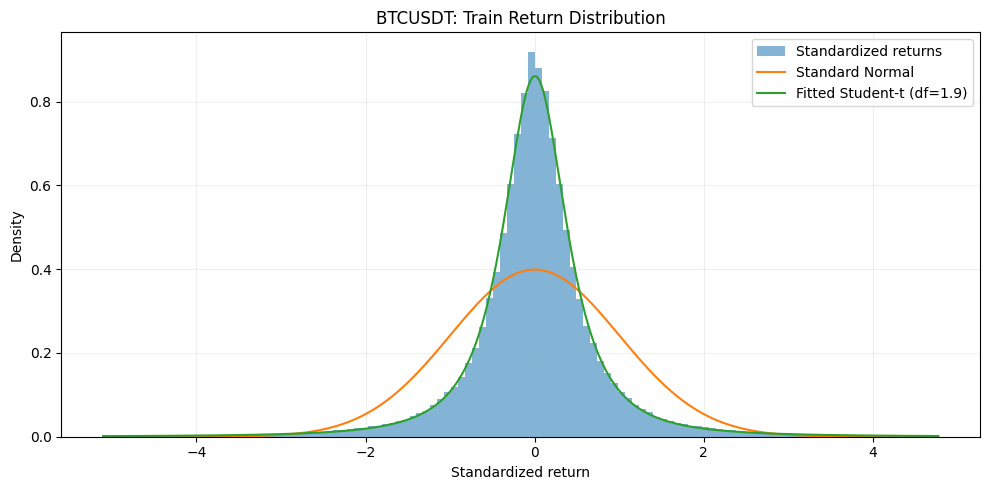

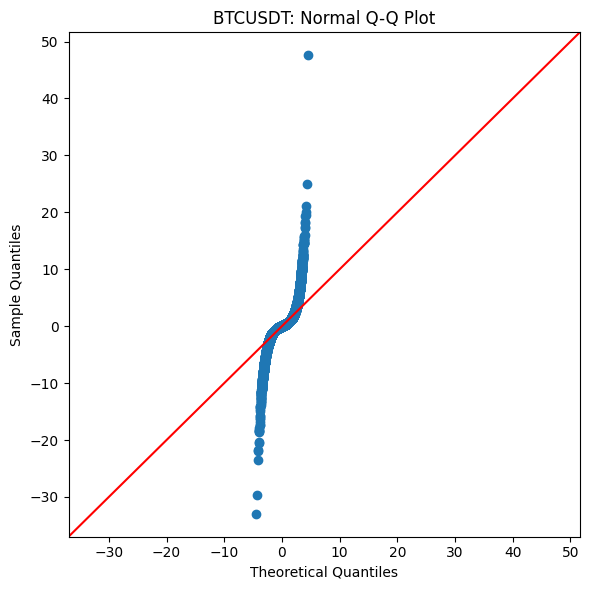

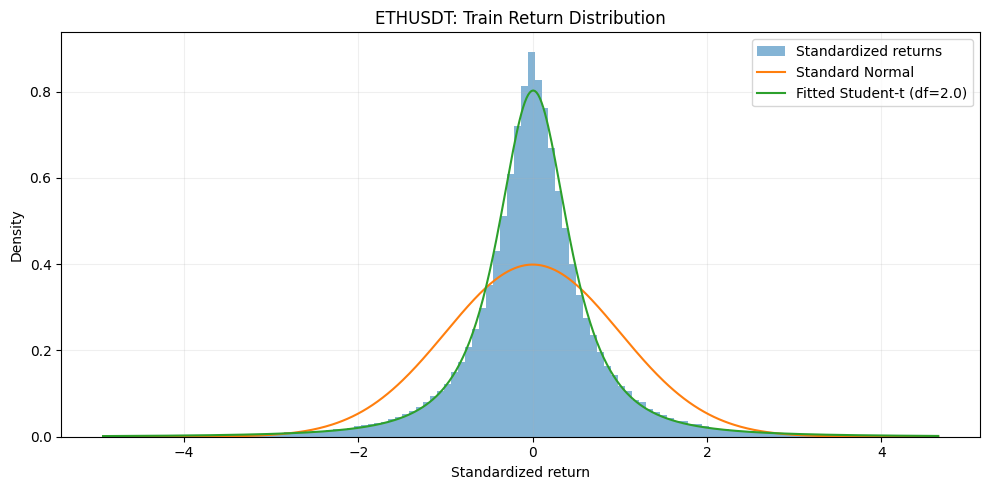

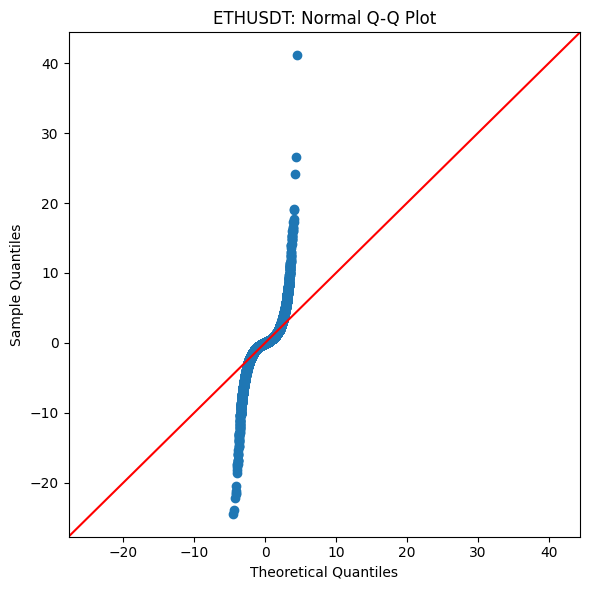

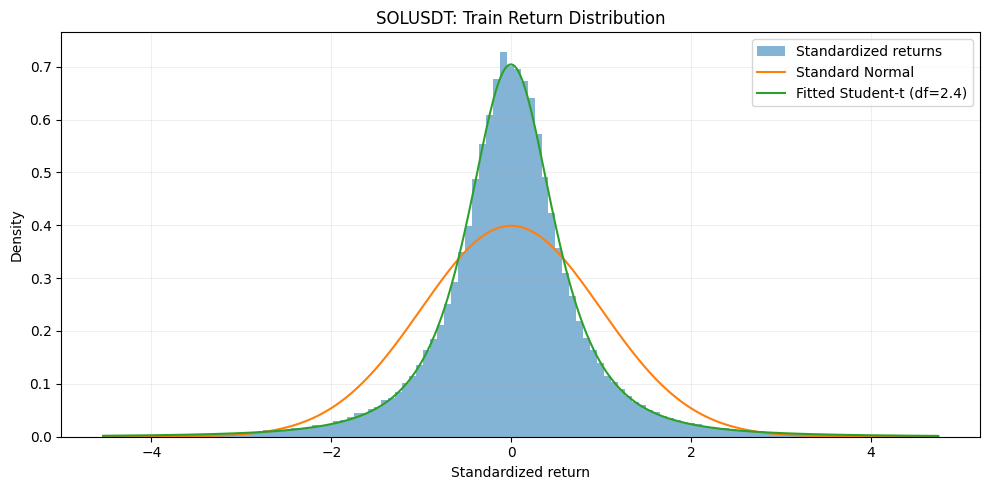

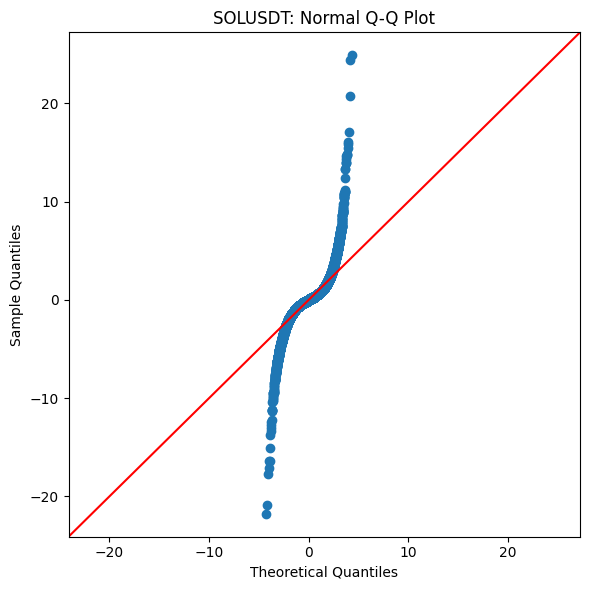

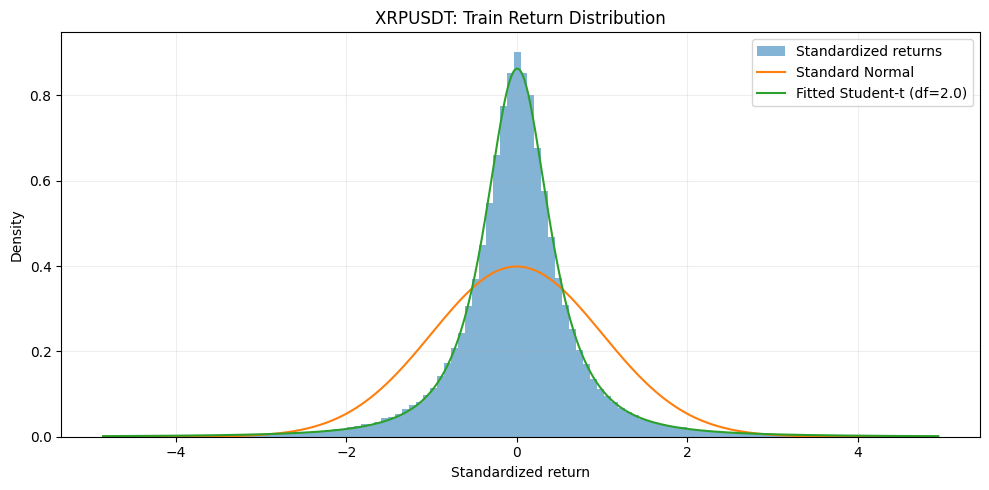

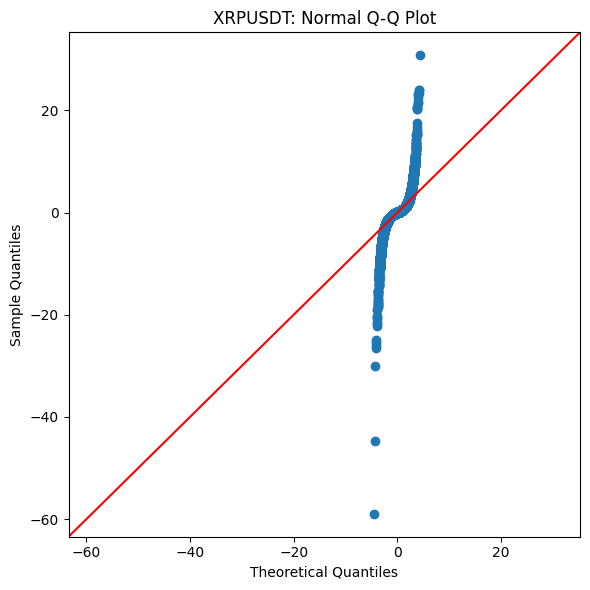

In [8]:
for symbol in SYMBOLS:

    x = (
        eda_df.loc[
            eda_df[
                "symbol"
            ].eq(symbol),
            "return",
        ]
        .to_numpy(
            dtype=float
        )
    )

    z = (
        (
            x
            - np.mean(
                x
            )
        )
        / np.std(
            x,
            ddof=1,
        )
    )

    t_df, t_loc, t_scale = (
        stats.t.fit(
            z
        )
    )

    low, high = np.quantile(
        z,
        [
            0.0025,
            0.9975,
        ],
    )

    grid = np.linspace(
        low,
        high,
        500,
    )

    plt.figure(
        figsize=(
            10,
            5,
        )
    )

    plt.hist(
        z[
            (
                z >= low
            )
            & (
                z <= high
            )
        ],
        bins=120,
        density=True,
        alpha=0.55,
        label="Standardized returns",
    )

    plt.plot(
        grid,
        stats.norm.pdf(
            grid,
        ),
        label="Standard Normal",
        linewidth=1.5,
    )

    plt.plot(
        grid,
        stats.t.pdf(
            grid,
            df=t_df,
            loc=t_loc,
            scale=t_scale,
        ),
        label=(
            "Fitted Student-t "
            f"(df={t_df:.1f})"
        ),
        linewidth=1.5,
    )

    plt.title(
        f"{symbol}: Train Return Distribution"
    )

    plt.xlabel(
        "Standardized return"
    )

    plt.ylabel(
        "Density"
    )

    plt.legend()

    plt.grid(
        alpha=0.20
    )

    plt.tight_layout()

    plt.savefig(
        FIGURE_ROOT
        / f"{symbol}_return_distribution.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()


    plt.figure(
        figsize=(
            6,
            6,
        )
    )

    qqplot(
        z,
        line="45",
        fit=True,
        ax=plt.gca(),
    )

    plt.title(
        f"{symbol}: Normal Q-Q Plot"
    )

    plt.tight_layout()

    plt.savefig(
        FIGURE_ROOT
        / f"{symbol}_normal_qq.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

## 9. Distribution tests

### Jarque–Bera
Null: returns are normally distributed.

### Student-t KS diagnostic
A Student-t distribution is fit to the same return sample and a KS statistic is reported.

Because the Student-t parameters are estimated on the tested data, the ordinary KS p-value should be treated as a **goodness-of-fit diagnostic**, not as an exact finite-sample specification test.

In [9]:
distribution_rows = []

for symbol in SYMBOLS:

    x = (
        eda_df.loc[
            eda_df[
                "symbol"
            ].eq(symbol),
            "return",
        ]
        .to_numpy(
            dtype=float
        )
    )

    jb = stats.jarque_bera(
        x
    )

    t_df, t_loc, t_scale = (
        stats.t.fit(
            x
        )
    )

    ks = stats.kstest(
        x,
        "t",
        args=(
            t_df,
            t_loc,
            t_scale,
        ),
    )

    distribution_rows.append({
        "symbol":
            symbol,

        "jarque_bera_stat":
            float(
                jb.statistic
            ),

        "jarque_bera_pvalue":
            float(
                jb.pvalue
            ),

        "normality_rejected_5pct":
            bool(
                jb.pvalue
                < 0.05
            ),

        "student_t_df":
            float(
                t_df
            ),

        "student_t_loc":
            float(
                t_loc
            ),

        "student_t_scale":
            float(
                t_scale
            ),

        "student_t_ks_stat":
            float(
                ks.statistic
            ),

        "student_t_ks_pvalue_diagnostic":
            float(
                ks.pvalue
            ),

        "student_t_ks_rejected_5pct_diagnostic":
            bool(
                ks.pvalue
                < 0.05
            ),
    })


distribution_tests_df = (
    pd.DataFrame(
        distribution_rows
    )
)

display(
    distribution_tests_df
)

distribution_tests_df.to_csv(
    RESULTS_ROOT
    / "distribution_tests.csv",
    index=False,
)

,symbol,jarque_bera_stat,jarque_bera_pvalue,normality_rejected_5pct,student_t_df,student_t_loc,student_t_scale,student_t_ks_stat,student_t_ks_pvalue_diagnostic,student_t_ks_rejected_5pct_diagnostic
0,BTCUSDT,4.442589e+07,0.0,True,1.975350,0.000030,0.001768,0.007002,8.666887e-11,True
1,ETHUSDT,2.583678e+07,0.0,True,1.976161,0.000028,0.002264,0.007687,6.472411e-13,True
2,SOLUSDT,5.064785e+06,0.0,True,2.375455,0.000009,0.003848,0.012781,3.568624e-20,True
3,XRPUSDT,1.753981e+08,0.0,True,1.977759,0.000023,0.002370,0.010276,1.807345e-20,True


## 10. Stationarity tests

The daily EDA used ADF/KPSS-style diagnostics. Here we report all three common tests correctly:

- **ADF**: unit-root null;
- **Phillips–Perron**: unit-root null;
- **KPSS**: stationarity null.

Tests are applied to:

1. raw intraday returns;
2. log squared returns.

This avoids the earlier ambiguity where a KPSS calculation was labeled as Phillips–Perron.

In [10]:
stationarity_rows = []

ADF_MAX_LAG = min(
    ARCH_LM_LAGS,
    48,
)

for symbol in SYMBOLS:

    current = (
        eda_df.loc[
            eda_df[
                "symbol"
            ].eq(symbol)
        ]
    )

    series_map = {
        "return":
            current[
                "return"
            ]
            .to_numpy(
                dtype=float
            ),

        "log_squared_return":
            current[
                "log_squared_return"
            ]
            .to_numpy(
                dtype=float
            ),
    }

    for series_name, x in (
        series_map.items()
    ):

        adf_result = adfuller(
            x,
            maxlag=ADF_MAX_LAG,
            regression="c",
            autolag="AIC",
        )

        pp_result = PhillipsPerron(
            x,
            trend="c",
        )

        with warnings.catch_warnings():
            warnings.simplefilter(
                "ignore"
            )

            kpss_result = kpss(
                x,
                regression="c",
                nlags="auto",
            )

        stationarity_rows.append({
            "symbol":
                symbol,

            "series":
                series_name,

            "adf_stat":
                float(
                    adf_result[0]
                ),

            "adf_pvalue":
                float(
                    adf_result[1]
                ),

            "adf_reject_unit_root_5pct":
                bool(
                    adf_result[1]
                    < 0.05
                ),

            "pp_stat":
                float(
                    pp_result.stat
                ),

            "pp_pvalue":
                float(
                    pp_result.pvalue
                ),

            "pp_reject_unit_root_5pct":
                bool(
                    pp_result.pvalue
                    < 0.05
                ),

            "kpss_stat":
                float(
                    kpss_result[0]
                ),

            "kpss_pvalue":
                float(
                    kpss_result[1]
                ),

            "kpss_reject_stationarity_5pct":
                bool(
                    kpss_result[1]
                    < 0.05
                ),
        })


stationarity_df = pd.DataFrame(
    stationarity_rows
)

display(
    stationarity_df
)

stationarity_df.to_csv(
    RESULTS_ROOT
    / "stationarity_tests.csv",
    index=False,
)

,symbol,series,adf_stat,adf_pvalue,adf_reject_unit_root_5pct,pp_stat,pp_pvalue,pp_reject_unit_root_5pct,kpss_stat,kpss_pvalue,kpss_reject_stationarity_5pct
0,BTCUSDT,return,-124.595683,0.0,True,-504.616145,0.0,True,0.071211,0.10,False
1,BTCUSDT,log_squared_return,-56.106257,0.0,True,-816.097525,0.0,True,11.065342,0.01,True
2,ETHUSDT,return,-125.317365,0.0,True,-497.046175,0.0,True,0.116441,0.10,False
3,ETHUSDT,log_squared_return,-58.846663,0.0,True,-800.615558,0.0,True,14.393249,0.01,True
4,SOLUSDT,return,-92.988786,0.0,True,-373.840883,0.0,True,0.230120,0.10,False
5,SOLUSDT,log_squared_return,-48.475733,0.0,True,-558.792769,0.0,True,23.089084,0.01,True
6,XRPUSDT,return,-117.805342,0.0,True,-475.332039,0.0,True,0.090315,0.10,False
7,XRPUSDT,log_squared_return,-59.113388,0.0,True,-741.126481,0.0,True,7.649993,0.01,True


## 11. Autocorrelation plots

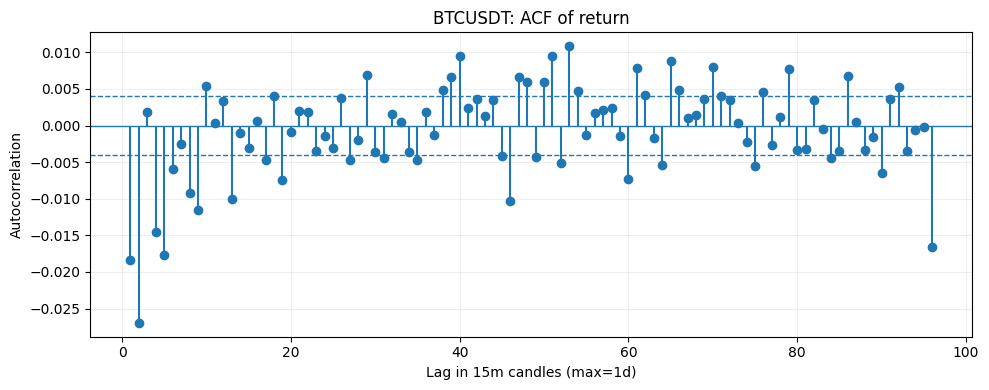

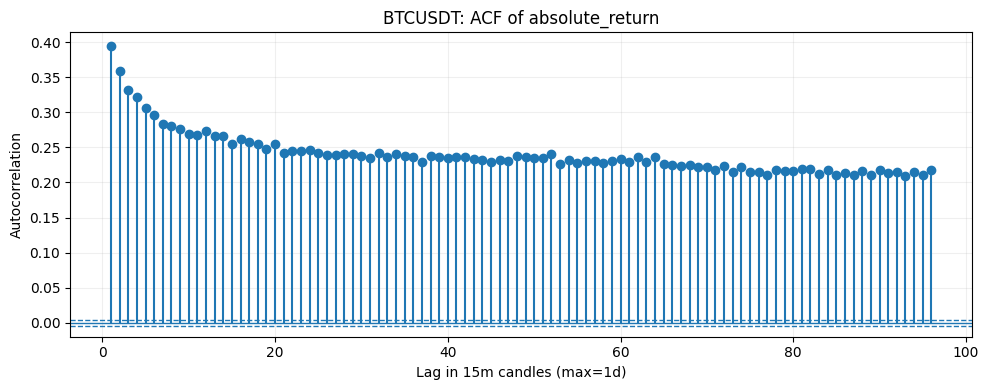

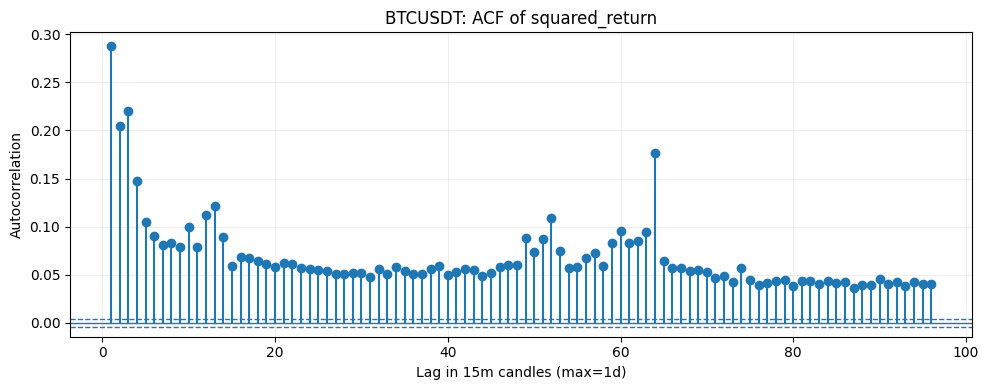

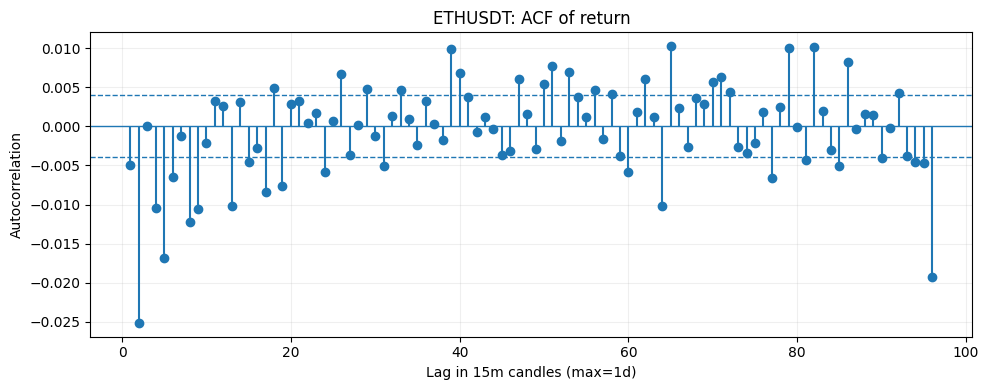

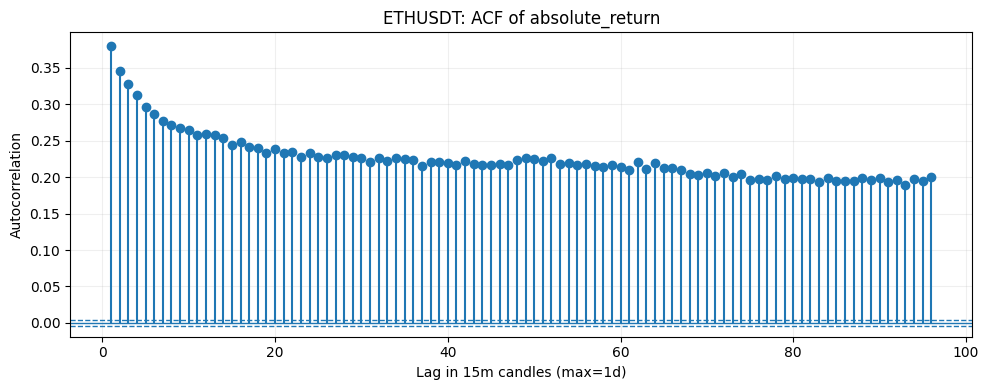

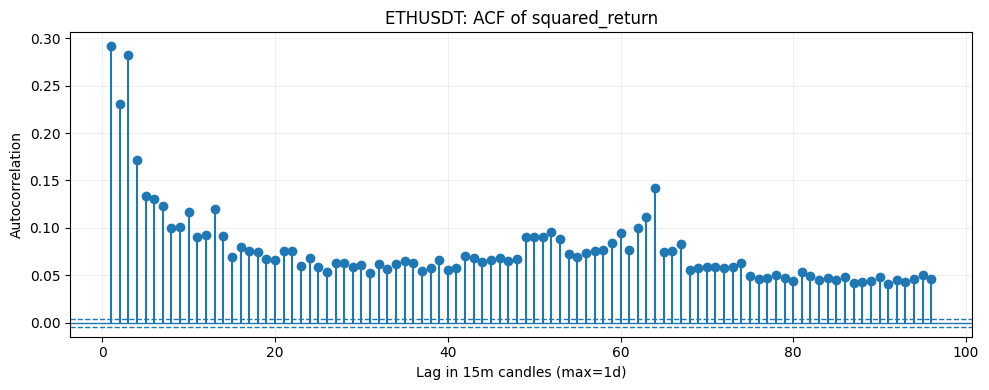

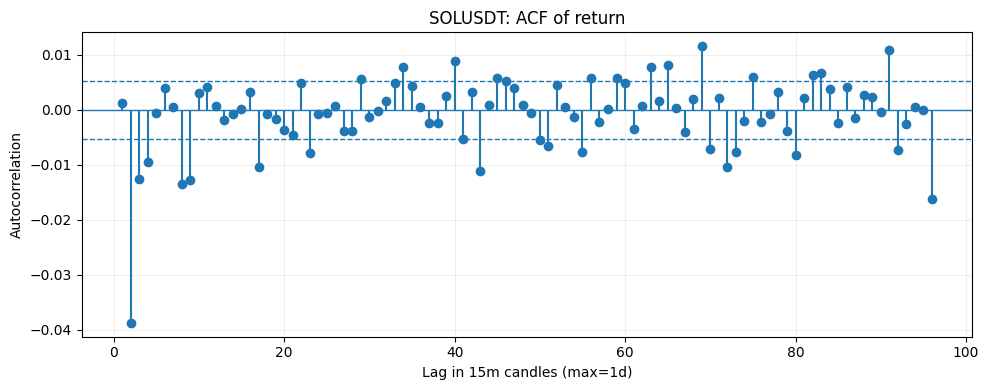

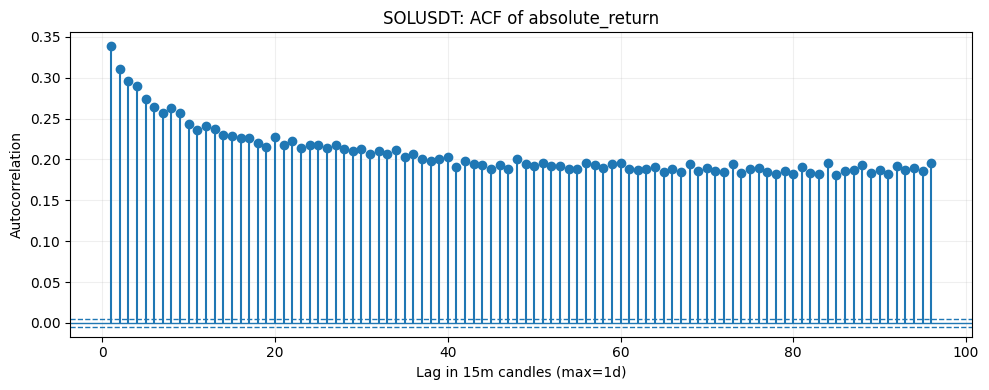

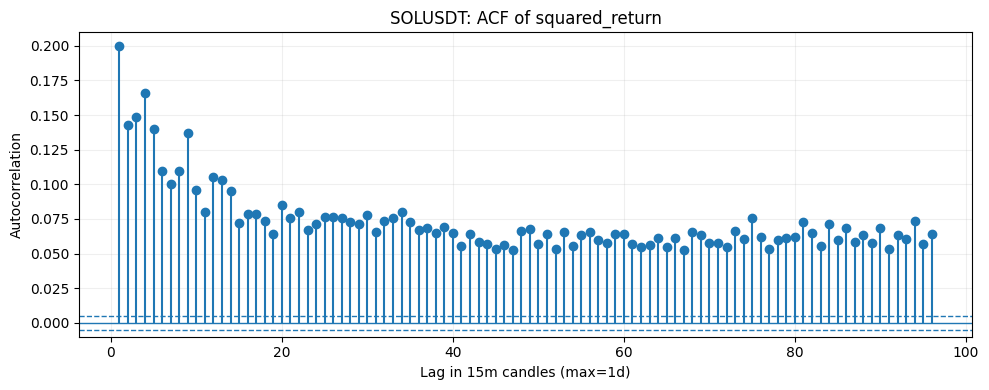

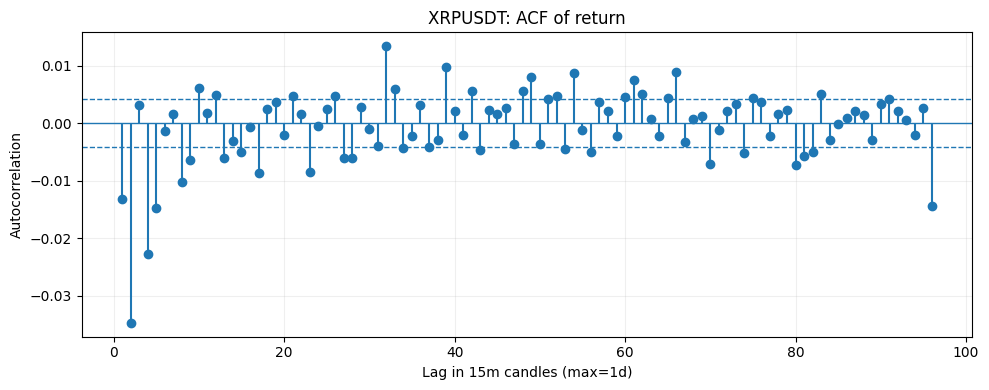

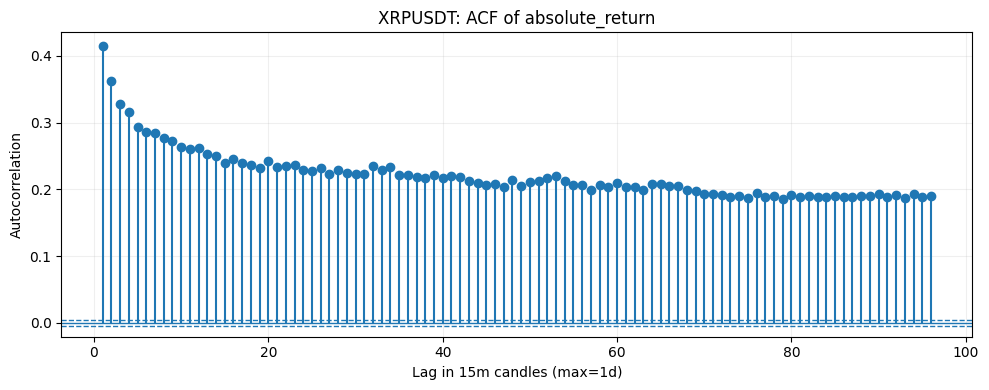

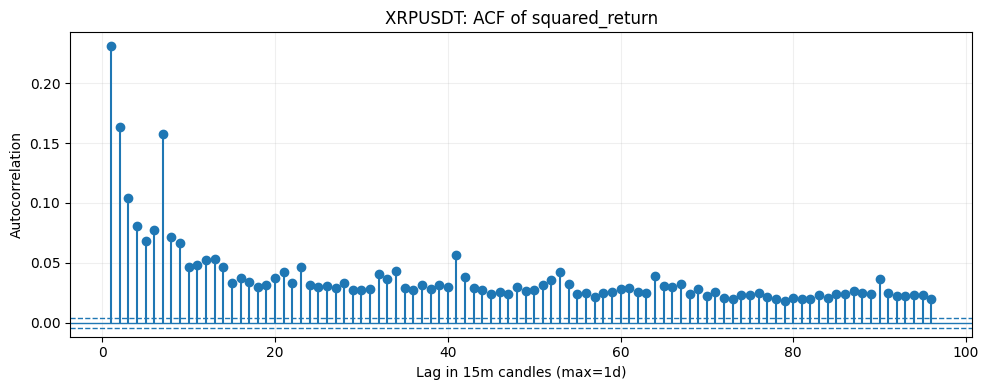

,symbol,series,duration,lag_bars,acf
0,BTCUSDT,return,1h,4,-0.014484
1,BTCUSDT,return,4h,16,0.000660
2,BTCUSDT,return,12h,48,0.005892
3,BTCUSDT,return,1d,96,-0.016531
4,BTCUSDT,absolute_return,1h,4,0.322260
5,BTCUSDT,absolute_return,4h,16,0.261291
6,BTCUSDT,absolute_return,12h,48,0.237088
7,BTCUSDT,absolute_return,1d,96,0.217797
8,BTCUSDT,squared_return,1h,4,0.147204
9,BTCUSDT,squared_return,4h,16,0.068386


In [11]:
acf_value_rows = []

for symbol in SYMBOLS:

    current = (
        eda_df.loc[
            eda_df[
                "symbol"
            ].eq(symbol)
        ]
    )

    series_map = {
        "return":
            current[
                "return"
            ]
            .to_numpy(
                dtype=float
            ),

        "absolute_return":
            current[
                "absolute_return"
            ]
            .to_numpy(
                dtype=float
            ),

        "squared_return":
            current[
                "squared_return"
            ]
            .to_numpy(
                dtype=float
            ),
    }

    for (
        series_name,
        x,
    ) in (
        series_map.items()
    ):

        values = acf(
            x,
            nlags=ACF_MAX_LAGS,
            fft=True,
            missing="drop",
        )

        for (
            duration,
            lag_bars,
        ) in (
            VALID_DIAGNOSTIC_LAGS.items()
        ):
            if lag_bars <= ACF_MAX_LAGS:
                acf_value_rows.append({
                    "symbol":
                        symbol,

                    "series":
                        series_name,

                    "duration":
                        duration,

                    "lag_bars":
                        lag_bars,

                    "acf":
                        float(
                            values[
                                lag_bars
                            ]
                        ),
                })

        plt.figure(
            figsize=(
                10,
                4,
            )
        )

        plt.stem(
            np.arange(
                1,
                len(
                    values
                ),
            ),
            values[
                1:
            ],
            basefmt=" ",
        )

        plt.axhline(
            0.0,
            linewidth=1.0,
        )

        confidence = (
            1.96
            / math.sqrt(
                len(
                    x
                )
            )
        )

        plt.axhline(
            confidence,
            linestyle="--",
            linewidth=1.0,
        )

        plt.axhline(
            -confidence,
            linestyle="--",
            linewidth=1.0,
        )

        plt.title(
            f"{symbol}: ACF of {series_name}"
        )

        plt.xlabel(
            (
                f"Lag in {KLINE_INTERVAL} candles "
                f"(max={ACF_MAX_DURATION})"
            )
        )

        plt.ylabel(
            "Autocorrelation"
        )

        plt.grid(
            alpha=0.20
        )

        plt.tight_layout()

        plt.savefig(
            FIGURE_ROOT
            / (
                f"{symbol}_acf_"
                f"{series_name}.png"
            ),
            dpi=200,
            bbox_inches="tight",
        )

        plt.show()


acf_values_df = pd.DataFrame(
    acf_value_rows
)

display(
    acf_values_df
)

acf_values_df.to_csv(
    RESULTS_ROOT
    / "acf_selected_lags.csv",
    index=False,
)

## 12. Ljung–Box serial-correlation tests

The same elapsed-time lags are used regardless of candle interval.

Tests are run on:

- returns;
- absolute returns;
- squared returns.

Strong rejection for absolute / squared returns is evidence of volatility clustering.

In [12]:
ljung_box_rows = []

lag_values = sorted(
    set(
        VALID_DIAGNOSTIC_LAGS.values()
    )
)

for symbol in SYMBOLS:

    current = (
        eda_df.loc[
            eda_df[
                "symbol"
            ].eq(symbol)
        ]
    )

    series_map = {
        "return":
            current[
                "return"
            ]
            .to_numpy(
                dtype=float
            ),

        "absolute_return":
            current[
                "absolute_return"
            ]
            .to_numpy(
                dtype=float
            ),

        "squared_return":
            current[
                "squared_return"
            ]
            .to_numpy(
                dtype=float
            ),
    }

    for (
        series_name,
        x,
    ) in (
        series_map.items()
    ):

        result = acorr_ljungbox(
            x,
            lags=lag_values,
            return_df=True,
        )

        for (
            duration,
            lag_bars,
        ) in (
            VALID_DIAGNOSTIC_LAGS.items()
        ):

            ljung_box_rows.append({
                "symbol":
                    symbol,

                "series":
                    series_name,

                "duration":
                    duration,

                "lag_bars":
                    lag_bars,

                "lb_stat":
                    float(
                        result.loc[
                            lag_bars,
                            "lb_stat",
                        ]
                    ),

                "lb_pvalue":
                    float(
                        result.loc[
                            lag_bars,
                            "lb_pvalue",
                        ]
                    ),

                "reject_no_autocorrelation_5pct":
                    bool(
                        result.loc[
                            lag_bars,
                            "lb_pvalue",
                        ]
                        < 0.05
                    ),
            })


ljung_box_df = pd.DataFrame(
    ljung_box_rows
)

display(
    ljung_box_df
)

ljung_box_df.to_csv(
    RESULTS_ROOT
    / "ljung_box_tests.csv",
    index=False,
)

,symbol,series,duration,lag_bars,lb_stat,lb_pvalue,reject_no_autocorrelation_5pct
0,BTCUSDT,return,1h,4,3.107769e+02,5.126934e-66,True
1,BTCUSDT,return,4h,16,4.865431e+02,2.297997e-93,True
2,BTCUSDT,return,12h,48,6.534590e+02,3.536838e-107,True
3,BTCUSDT,return,1d,96,9.759845e+02,1.133121e-145,True
4,BTCUSDT,absolute_return,1h,4,1.211317e+05,0.000000e+00,True
5,BTCUSDT,absolute_return,4h,16,3.427428e+05,0.000000e+00,True
6,BTCUSDT,absolute_return,12h,48,7.894526e+05,0.000000e+00,True
7,BTCUSDT,absolute_return,1d,96,1.366081e+06,0.000000e+00,True
8,BTCUSDT,squared_return,1h,4,4.743358e+04,0.000000e+00,True
9,BTCUSDT,squared_return,4h,16,7.135818e+04,0.000000e+00,True


## 13. ARCH-LM test

Null: no remaining ARCH effect in returns up to the configured lag horizon.

Rejection supports conditional-heteroskedasticity models.

In [13]:
arch_lm_rows = []

for symbol in SYMBOLS:

    x = (
        eda_df.loc[
            eda_df[
                "symbol"
            ].eq(symbol),
            "return",
        ]
        .to_numpy(
            dtype=float
        )
    )

    lm_stat, lm_pvalue, f_stat, f_pvalue = (
        het_arch(
            x,
            nlags=ARCH_LM_LAGS,
        )
    )

    arch_lm_rows.append({
        "symbol":
            symbol,

        "lag_duration":
            ARCH_LM_DURATION,

        "lag_bars":
            ARCH_LM_LAGS,

        "lm_stat":
            float(
                lm_stat
            ),

        "lm_pvalue":
            float(
                lm_pvalue
            ),

        "f_stat":
            float(
                f_stat
            ),

        "f_pvalue":
            float(
                f_pvalue
            ),

        "reject_no_arch_5pct":
            bool(
                lm_pvalue
                < 0.05
            ),
    })


arch_lm_df = pd.DataFrame(
    arch_lm_rows
)

display(
    arch_lm_df
)

arch_lm_df.to_csv(
    RESULTS_ROOT
    / "arch_lm_tests.csv",
    index=False,
)

,symbol,lag_duration,lag_bars,lm_stat,lm_pvalue,f_stat,f_pvalue,reject_no_arch_5pct
0,BTCUSDT,4h,16,31620.132234,0.0,2271.324077,0.0,True
1,ETHUSDT,4h,16,37129.432381,0.0,2738.339428,0.0,True
2,SOLUSDT,4h,16,12769.247868,0.0,878.609325,0.0,True
3,XRPUSDT,4h,16,19130.084197,0.0,1310.250555,0.0,True


## 14. Intraday time-of-day volatility seasonality

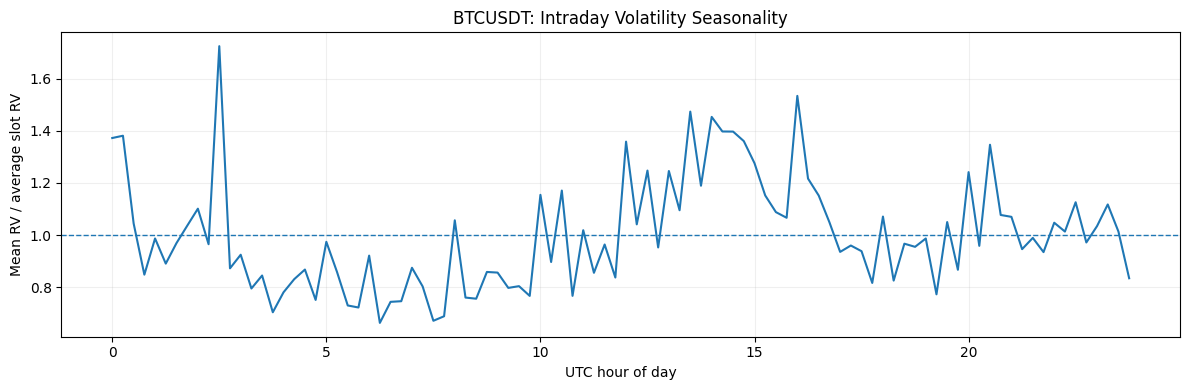

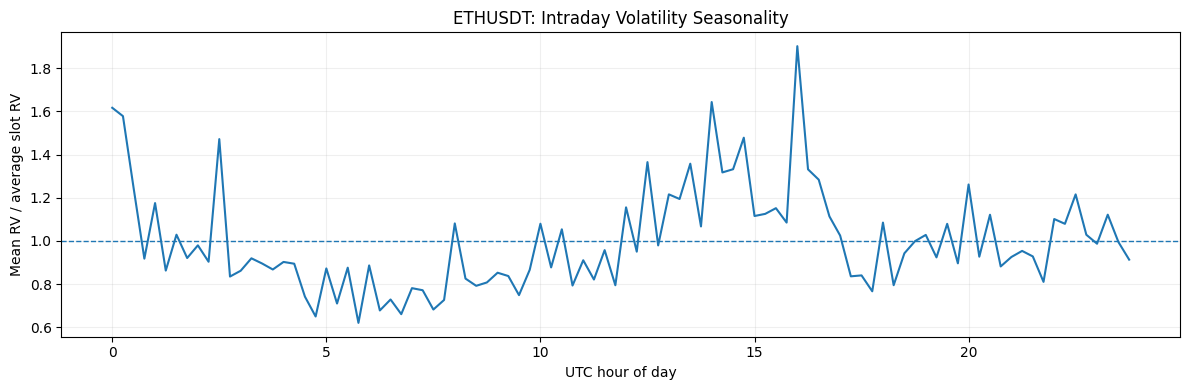

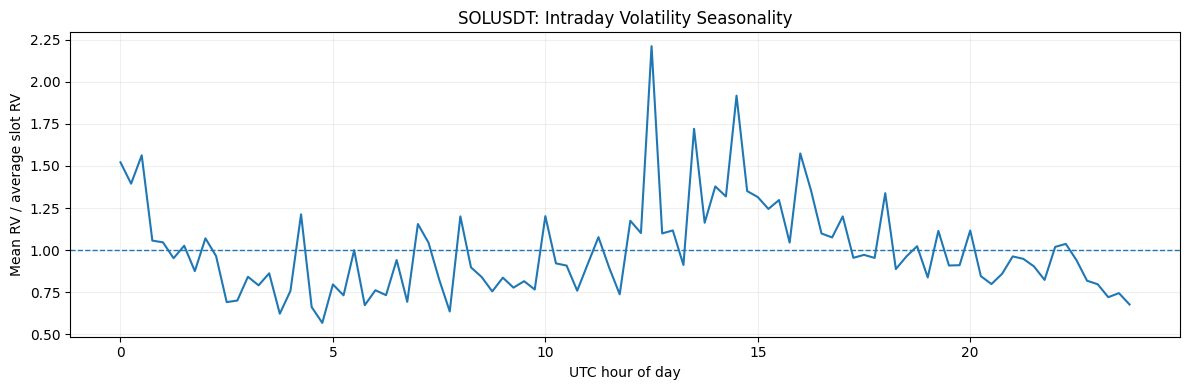

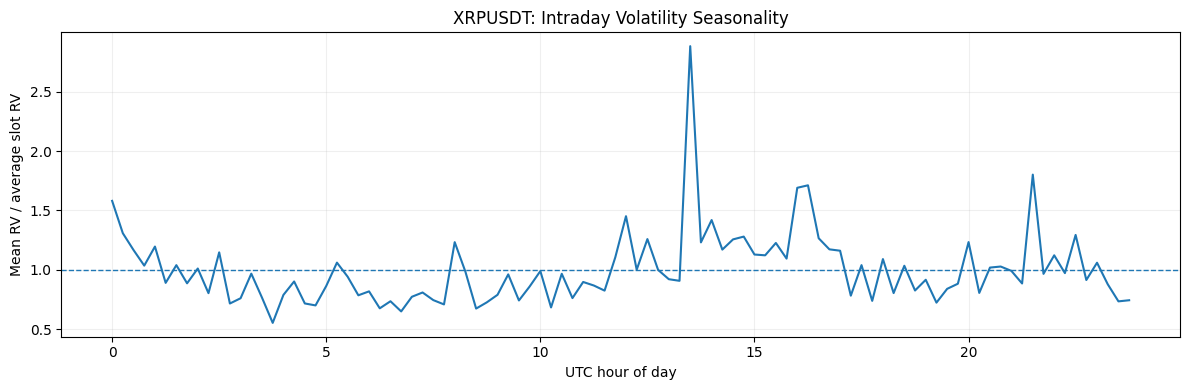

In [14]:
seasonality_df = (
    eda_df[
        [
            "symbol",
            "open_time",
            "squared_return",
        ]
    ]
    .copy()
)

seasonality_df[
    "minute_of_day"
] = (
    seasonality_df[
        "open_time"
    ].dt.hour
    * 60
    + seasonality_df[
        "open_time"
    ].dt.minute
)

time_of_day_df = (
    seasonality_df
    .groupby(
        [
            "symbol",
            "minute_of_day",
        ],
        as_index=False,
    )
    .agg(
        observations=(
            "squared_return",
            "size",
        ),

        mean_rv=(
            "squared_return",
            "mean",
        ),

        median_rv=(
            "squared_return",
            "median",
        ),
    )
)

time_of_day_df[
    "mean_rv_factor"
] = (
    time_of_day_df[
        "mean_rv"
    ]
    / time_of_day_df
    .groupby(
        "symbol"
    )[
        "mean_rv"
    ]
    .transform(
        "mean"
    )
)

time_of_day_df.to_csv(
    RESULTS_ROOT
    / "time_of_day_volatility_seasonality.csv",
    index=False,
)


for symbol in SYMBOLS:

    x = (
        time_of_day_df.loc[
            time_of_day_df[
                "symbol"
            ].eq(symbol)
        ]
        .sort_values(
            "minute_of_day"
        )
    )

    plt.figure(
        figsize=(
            12,
            4,
        )
    )

    plt.plot(
        x[
            "minute_of_day"
        ]
        / 60.0,
        x[
            "mean_rv_factor"
        ],
    )

    plt.axhline(
        1.0,
        linestyle="--",
        linewidth=1.0,
    )

    plt.xlabel(
        "UTC hour of day"
    )

    plt.ylabel(
        "Mean RV / average slot RV"
    )

    plt.title(
        f"{symbol}: Intraday Volatility Seasonality"
    )

    plt.grid(
        alpha=0.20
    )

    plt.tight_layout()

    plt.savefig(
        FIGURE_ROOT
        / (
            f"{symbol}_time_of_day_"
            "volatility.png"
        ),
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

## 15. Day-of-week volatility seasonality

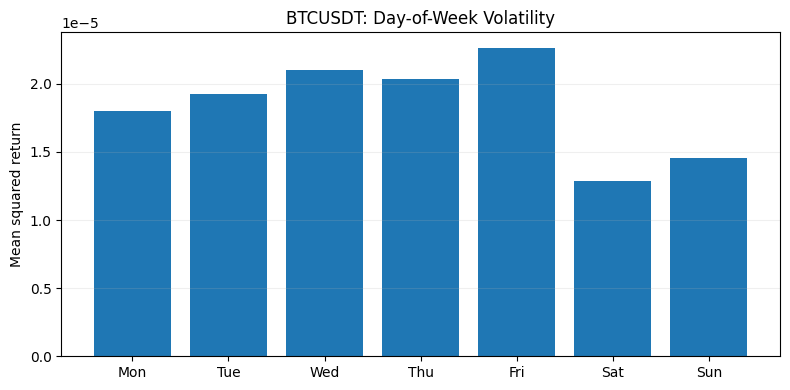

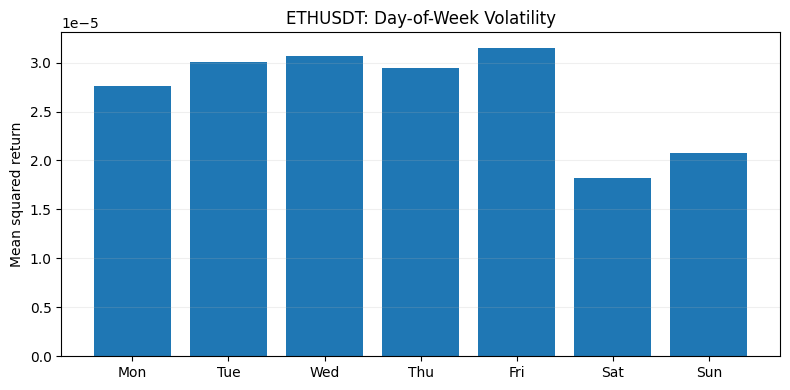

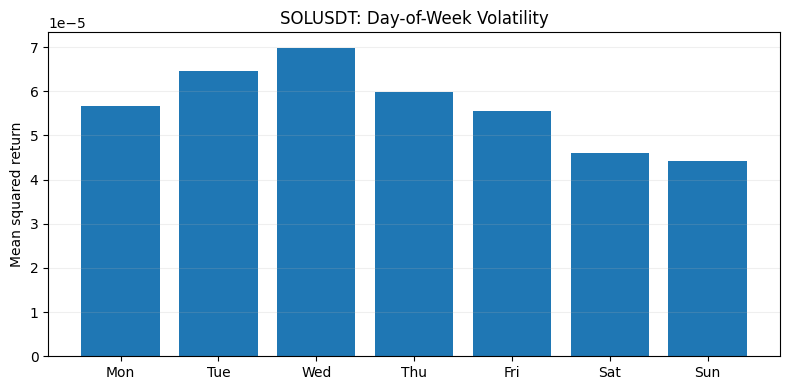

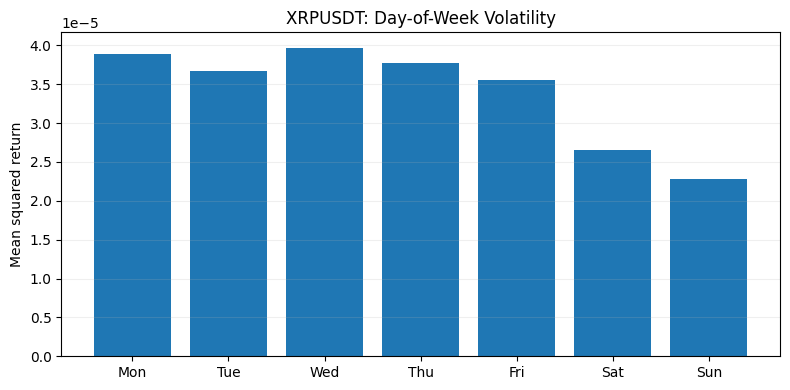

In [15]:
dow_df = (
    eda_df[
        [
            "symbol",
            "open_time",
            "squared_return",
        ]
    ]
    .copy()
)

dow_df[
    "day_of_week"
] = (
    dow_df[
        "open_time"
    ]
    .dt.dayofweek
)

dow_summary_df = (
    dow_df
    .groupby(
        [
            "symbol",
            "day_of_week",
        ],
        as_index=False,
    )
    .agg(
        observations=(
            "squared_return",
            "size",
        ),

        mean_rv=(
            "squared_return",
            "mean",
        ),

        median_rv=(
            "squared_return",
            "median",
        ),
    )
)

DOW_LABELS = {
    0:
        "Mon",
    1:
        "Tue",
    2:
        "Wed",
    3:
        "Thu",
    4:
        "Fri",
    5:
        "Sat",
    6:
        "Sun",
}

dow_summary_df[
    "day_name"
] = (
    dow_summary_df[
        "day_of_week"
    ]
    .map(
        DOW_LABELS
    )
)

dow_summary_df.to_csv(
    RESULTS_ROOT
    / "day_of_week_volatility_seasonality.csv",
    index=False,
)


for symbol in SYMBOLS:

    x = (
        dow_summary_df.loc[
            dow_summary_df[
                "symbol"
            ].eq(symbol)
        ]
        .sort_values(
            "day_of_week"
        )
    )

    plt.figure(
        figsize=(
            8,
            4,
        )
    )

    plt.bar(
        x[
            "day_name"
        ],
        x[
            "mean_rv"
        ],
    )

    plt.ylabel(
        "Mean squared return"
    )

    plt.title(
        f"{symbol}: Day-of-Week Volatility"
    )

    plt.grid(
        axis="y",
        alpha=0.20,
    )

    plt.tight_layout()

    plt.savefig(
        FIGURE_ROOT
        / f"{symbol}_day_of_week_volatility.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

## 16. Cross-asset contemporaneous dependence

In [16]:
return_wide = (
    eda_df
    .pivot(
        index="open_time",
        columns="symbol",
        values="return",
    )
    .dropna()
)

squared_return_wide = (
    eda_df
    .pivot(
        index="open_time",
        columns="symbol",
        values="squared_return",
    )
    .dropna()
)

return_corr_df = (
    return_wide.corr()
)

squared_return_corr_df = (
    squared_return_wide.corr()
)

display(
    return_corr_df
)

display(
    squared_return_corr_df
)

return_corr_df.to_csv(
    RESULTS_ROOT
    / "cross_asset_return_correlation.csv"
)

squared_return_corr_df.to_csv(
    RESULTS_ROOT
    / "cross_asset_squared_return_correlation.csv"
)

symbol,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT
symbol,,,,
BTCUSDT,1.000000,0.850771,0.603089,0.601554
ETHUSDT,0.850771,1.000000,0.632029,0.618043
SOLUSDT,0.603089,0.632029,1.000000,0.484584
XRPUSDT,0.601554,0.618043,0.484584,1.000000


symbol,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT
symbol,,,,
BTCUSDT,1.000000,0.762464,0.405302,0.351098
ETHUSDT,0.762464,1.000000,0.440798,0.334858
SOLUSDT,0.405302,0.440798,1.000000,0.215197
XRPUSDT,0.351098,0.334858,0.215197,1.000000


## 17. Dynamic rolling historical-volatility visualization

This is descriptive EDA only.

The rolling standard deviation includes the current observed return and is **not** a predictive model feature unless explicitly lagged in a forecasting design.

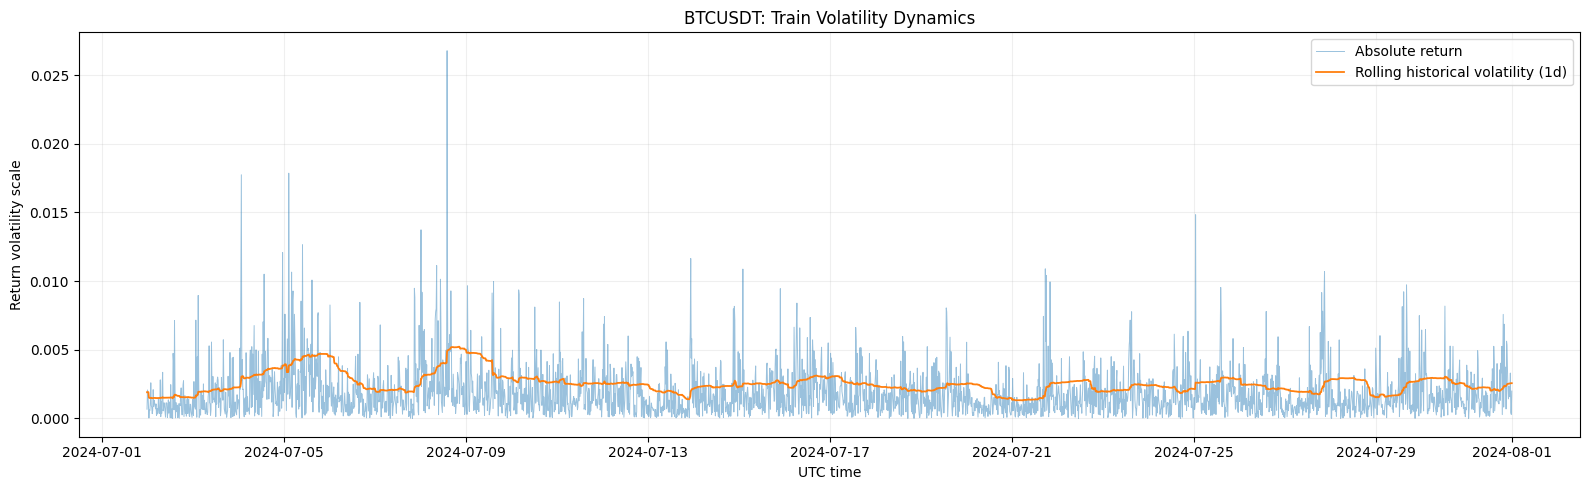

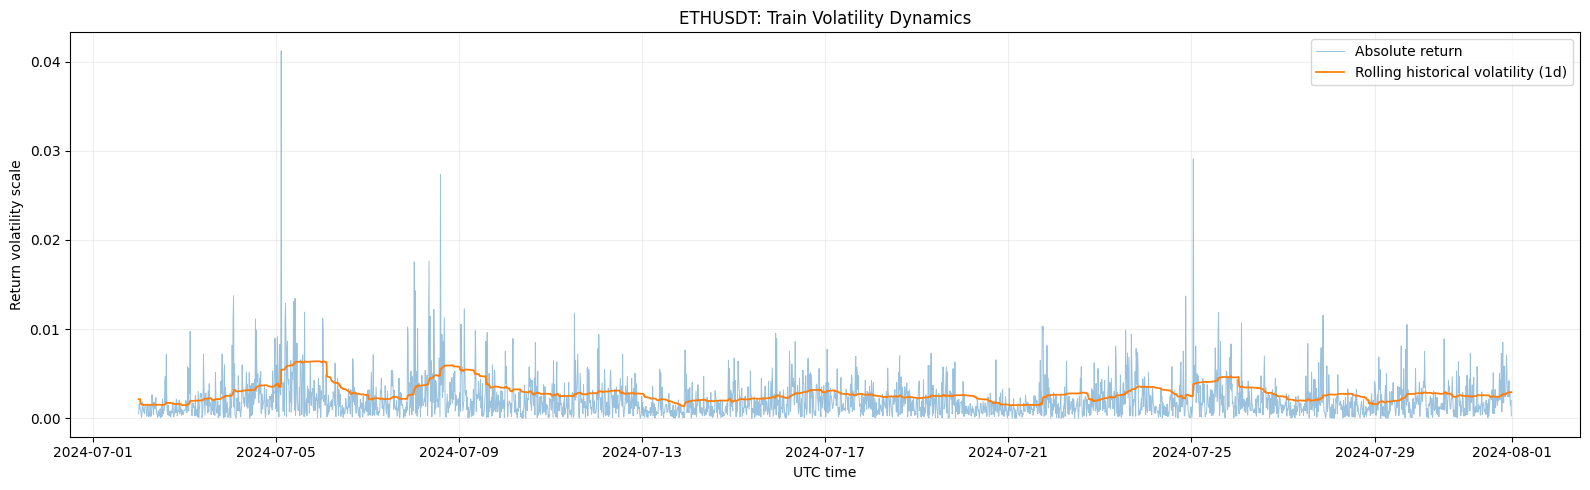

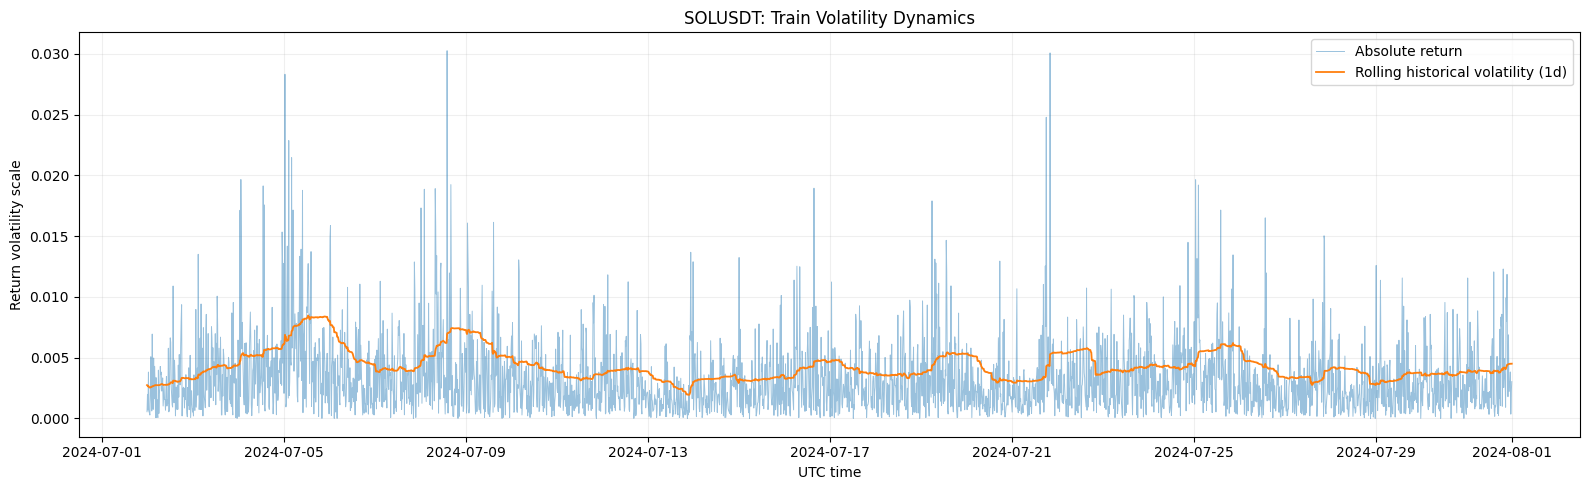

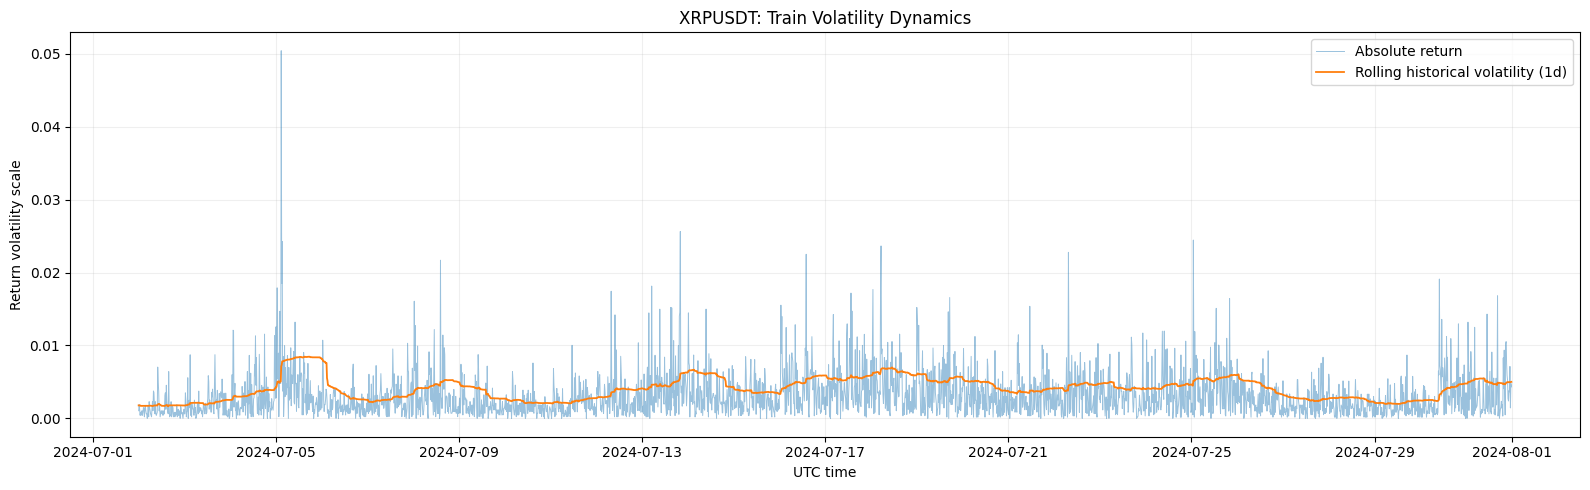

In [17]:
def strict_rolling_std(
    values,
    times,
    bars,
    ddof=1,
):
    rolling_std = (
        values
        .rolling(
            window=bars,
            min_periods=bars,
        )
        .std(
            ddof=ddof
        )
    )

    count = (
        values
        .rolling(
            window=bars,
            min_periods=bars,
        )
        .count()
    )

    start_time = (
        times.shift(
            bars
            - 1
        )
    )

    exact_span = (
        (
            times
            - start_time
        )
        .eq(
            (
                bars
                - 1
            )
            * INTERVAL_DELTA
        )
    )

    return rolling_std.where(
        count.eq(
            bars
        )
        & exact_span
    )


plot_duration = pd.Timedelta(
    TIMESERIES_PLOT_DURATION
)

for symbol in SYMBOLS:

    x = (
        eda_df.loc[
            eda_df[
                "symbol"
            ].eq(symbol)
        ]
        .sort_values(
            "open_time"
        )
        .copy()
    )

    x[
        "rolling_volatility"
    ] = strict_rolling_std(
        values=x[
            "return"
        ],
        times=x[
            "open_time"
        ],
        bars=ROLLING_VOLATILITY_BARS,
        ddof=1,
    )

    plot_end = (
        x[
            "open_time"
        ].max()
        + INTERVAL_DELTA
    )

    plot_start = (
        plot_end
        - plot_duration
    )

    plot_x = (
        x.loc[
            x[
                "open_time"
            ].ge(
                plot_start
            )
        ]
    )

    plt.figure(
        figsize=(
            16,
            5,
        )
    )

    plt.plot(
        plot_x[
            "open_time"
        ],
        plot_x[
            "absolute_return"
        ],
        label="Absolute return",
        linewidth=0.7,
        alpha=0.45,
    )

    plt.plot(
        plot_x[
            "open_time"
        ],
        plot_x[
            "rolling_volatility"
        ],
        label=(
            "Rolling historical volatility "
            f"({ROLLING_VOLATILITY_WINDOW})"
        ),
        linewidth=1.3,
    )

    plt.title(
        f"{symbol}: Train Volatility Dynamics"
    )

    plt.xlabel(
        "UTC time"
    )

    plt.ylabel(
        "Return volatility scale"
    )

    plt.legend()

    plt.grid(
        alpha=0.20
    )

    plt.tight_layout()

    plt.savefig(
        FIGURE_ROOT
        / (
            f"{symbol}_rolling_volatility_"
            f"{ROLLING_VOLATILITY_WINDOW}.png"
        ),
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

## 18. Consolidated stylized-facts summary

In [18]:
summary_rows = []

for symbol in SYMBOLS:

    desc = (
        descriptive_df.loc[
            descriptive_df[
                "symbol"
            ].eq(symbol)
        ]
        .iloc[0]
    )

    jb = (
        distribution_tests_df.loc[
            distribution_tests_df[
                "symbol"
            ].eq(symbol)
        ]
        .iloc[0]
    )

    adf_return = (
        stationarity_df.loc[
            stationarity_df[
                "symbol"
            ].eq(symbol)
            & stationarity_df[
                "series"
            ].eq(
                "return"
            )
        ]
        .iloc[0]
    )

    pp_return = (
        stationarity_df.loc[
            stationarity_df[
                "symbol"
            ].eq(symbol)
            & stationarity_df[
                "series"
            ].eq(
                "return"
            )
        ]
        .iloc[0]
    )

    arch_row = (
        arch_lm_df.loc[
            arch_lm_df[
                "symbol"
            ].eq(symbol)
        ]
        .iloc[0]
    )

    sq_lb = (
        ljung_box_df.loc[
            ljung_box_df[
                "symbol"
            ].eq(symbol)
            & ljung_box_df[
                "series"
            ].eq(
                "squared_return"
            )
        ]
        .sort_values(
            "lag_bars"
        )
        .iloc[-1]
    )

    summary_rows.append({
        "symbol":
            symbol,

        "stationary_return_adf_5pct":
            bool(
                adf_return[
                    "adf_reject_unit_root_5pct"
                ]
            ),

        "stationary_return_pp_5pct":
            bool(
                pp_return[
                    "pp_reject_unit_root_5pct"
                ]
            ),

        "normality_rejected_5pct":
            bool(
                jb[
                    "normality_rejected_5pct"
                ]
            ),

        "excess_kurtosis":
            float(
                desc[
                    "excess_kurtosis"
                ]
            ),

        "arch_effect_rejected_5pct":
            bool(
                arch_row[
                    "reject_no_arch_5pct"
                ]
            ),

        "squared_return_serial_dependence_5pct":
            bool(
                sq_lb[
                    "reject_no_autocorrelation_5pct"
                ]
            ),
    })


stylized_facts_df = (
    pd.DataFrame(
        summary_rows
    )
)

display(
    stylized_facts_df
)

stylized_facts_df.to_csv(
    RESULTS_ROOT
    / "stylized_facts_summary.csv",
    index=False,
)

,symbol,stationary_return_adf_5pct,stationary_return_pp_5pct,normality_rejected_5pct,excess_kurtosis,arch_effect_rejected_5pct,squared_return_serial_dependence_5pct
0,BTCUSDT,True,True,True,66.200028,True,True
1,ETHUSDT,True,True,True,50.484279,True,True
2,SOLUSDT,True,True,True,29.547791,True,True
3,XRPUSDT,True,True,True,138.760525,True,True


## 19. Final QC and saved-output manifest

In [19]:
expected_output_files = [
    RESULTS_ROOT
    / "descriptive_statistics.csv",

    RESULTS_ROOT
    / "distribution_tests.csv",

    RESULTS_ROOT
    / "stationarity_tests.csv",

    RESULTS_ROOT
    / "acf_selected_lags.csv",

    RESULTS_ROOT
    / "ljung_box_tests.csv",

    RESULTS_ROOT
    / "arch_lm_tests.csv",

    RESULTS_ROOT
    / "time_of_day_volatility_seasonality.csv",

    RESULTS_ROOT
    / "day_of_week_volatility_seasonality.csv",

    RESULTS_ROOT
    / "cross_asset_return_correlation.csv",

    RESULTS_ROOT
    / "cross_asset_squared_return_correlation.csv",

    RESULTS_ROOT
    / "stylized_facts_summary.csv",
]

for path in (
    expected_output_files
):
    if not path.exists():
        raise FileNotFoundError(
            path
        )


assert (
    descriptive_df[
        "observations"
    ]
    .gt(
        1000
    )
    .all()
)

assert np.isfinite(
    descriptive_df[
        [
            "mean_return",
            "std_return",
            "annualized_volatility",
            "skewness",
            "excess_kurtosis",
        ]
    ]
    .to_numpy(
        dtype=float
    )
).all()


eda_manifest = {
    "created_at_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "kline_interval":
        KLINE_INTERVAL,

    "interval_minutes":
        INTERVAL_MINUTES,

    "eda_scope":
        "original_train_period_only",

    "eda_end_exclusive":
        VALIDATION_START.isoformat(),

    "diagnostic_lags":
        VALID_DIAGNOSTIC_LAGS,

    "acf_max_duration":
        ACF_MAX_DURATION,

    "arch_lm_duration":
        ARCH_LM_DURATION,

    "rolling_volatility_window":
        ROLLING_VOLATILITY_WINDOW,

    "bars_per_day":
        BARS_PER_DAY,

    "crypto_bars_per_year":
        BARS_PER_YEAR,

    "annualization_days":
        365,

    "formal_tests_use_untrimmed_data":
        True,

    "test_data_used":
        False,
}

(
    RESULTS_ROOT
    / "eda_manifest.json"
).write_text(
    json.dumps(
        eda_manifest,
        indent=2,
    ),
    encoding="utf-8",
)


print(
    "ALL INTRADAY EDA / STATISTICAL "
    "DIAGNOSTIC QC CHECKS PASSED."
)

print(
    "Test remains untouched."
)

ALL INTRADAY EDA / STATISTICAL DIAGNOSTIC QC CHECKS PASSED.
Test remains untouched.


# Interpretation guide

A typical volatility-modeling interpretation is:

- **ADF / PP reject unit root + KPSS does not reject stationarity**  
  → return process is consistent with stationarity.

- **Jarque–Bera rejects normality + large excess kurtosis**  
  → heavy-tailed return innovations; supports Student-t innovation assumptions.

- **Return ACF small, but absolute / squared-return ACF persistent**  
  → weak linear predictability in returns but strong volatility clustering.

- **Ljung–Box rejects for squared returns**  
  → serial dependence remains in conditional variance.

- **ARCH-LM rejects no-ARCH null**  
  → direct motivation for ARCH / GARCH-family conditional-volatility models.

- **Strong time-of-day volatility pattern**  
  → explicit intraday seasonality adjustment is justified.

These diagnostics are descriptive / inferential evidence for the modeling design. They are not a license to tune against Test.